Classification of Requests as Having a Resolution Time > 30 days or < 30 days based on the Neighborhood, Request Type, etc.

Steps:
1. Cut down on neighborhoods with very high average resolution times (outliers)
2. Correlation Matrices (neighborhood & request type vs. is_closed & request_status)
3. Feature Importance
4. Models
    a) Linear Regression - Naive Bayes
    b) Random Forest Classifier
    c) SVM (Support Vector Machine)
5. Validation
    a) Accuracy (optional)
    b) Precision
    c) Recall
    d) Qualitative Measures
6. Interpretation

TA Notes:
- EDA: do a correlation matrix and see corr between features & Y variable
- EDA: find out how to cut down on neighborhoods to focus on where there are very high resolution times
- Modeling: start with basic Naive Bayes - linear regression
- Random forest classifier - has good fine tuning parameters but doesn't generalize well on training so sometimes overlearns on testing data
- SVM (support vector machine): really good but takes a long time to run (especially on our big dataset, so can maybe take a smaller sample to do that)
- Feature importance - which independent features explain the variance/variability on Y variable the most (for ex. start date) - DROP those columns before modeling since they'd be highly correlated
- Validation: test accuracy based on these 3 & pick one at the end
- Look at different parameters & evaluation metrics - focus on either precision or recall (accuracy is not good) - which error is more costly in our case, and decide which model is best for this case on the basis of that metric
- Qualitative measures to look at: ease of deployment, how to make sense of results from model, (for ex. can't make sense of Random Forest but can interpret the others), which best avoids biases and considers ethics, etc.
- In final paper: focus on the project scoping aspect more

In [ ]:
import pandas as pd
import pandas as pd 
import numpy as np
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve


In [ ]:
# Step 1: Loading the cleaned dataset and parse datetime columns for analysis

csv_path = "clean3.csv"
df = pd.read_csv(csv_path, 
                 parse_dates=['create_date_et', 'closed_date_filled'], 
                 # engine = 'python')
                 engine='python')

In [93]:
# Quick overview to check column types, missing values, and sample entries
print(df.info())
print(df.head())
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316673 entries, 0 to 316672
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   _id                            316673 non-null  int64         
 1   group_id                       316673 non-null  int64         
 2   num_requests                   316673 non-null  int64         
 3   status_name                    316673 non-null  object        
 4   status_code                    316673 non-null  int64         
 5   dept                           316673 non-null  object        
 6   request_type_id                316673 non-null  int64         
 7   create_date_et                 316673 non-null  datetime64[ns]
 8   last_action_et                 316673 non-null  object        
 9   closed_date_et                 266448 non-null  object        
 10  origin                         316673 non-null  object        
 11  

In [94]:
# Defining our binary classification target:
# Label = 1 if request is still open or took longer than 30 days to resolve
df["label"] = (
    (df["resolution_time"] > 30) |
    (df["request_status"].str.lower() == "open")
).astype(int)

In [95]:
# FEATURE ENGINEERING
df = df.sort_values("create_date_et")

In [102]:
# Feature 1: Time since last similar request in the same neighborhood
# This helps capture temporal clustering of issues
# Warning is expected due to chained assignment; handled properly anyway

df["time_since_last"] = (
    df.groupby(["neighborhood", "request_type_name"])["create_date_et"]
      .diff()
      .dt.total_seconds()
      / 86400
).fillna(np.nan)
df["time_since_last"].fillna(df["time_since_last"].median(), inplace=True)

/var/folders/45/f_1kv2y91559bz3kljjwtpxw0000gn/T/ipykernel_51686/563017397.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["time_since_last"].fillna(df["time_since_last"].median(), inplace=True)


In [104]:
# Feature 2: Rolling average resolution time per request type
# Gives context on how long such issues usually take to resolve
df["rolling_avg_closure"] = (
    df.groupby("request_type_name")["resolution_time"]
      .expanding()
      .mean()
      .shift()
      .reset_index(level=0, drop=True)
).fillna(df["resolution_time"].mean())

In [106]:
## TAKING TOO LONG TO RUN ##

# # department workload = # of tickets open at creation time
# df["closure_date"] = df["create_date_et"] + pd.to_timedelta(df["resolution_time"], unit="D")
# df["dept_workload"] = df.apply(
#     lambda row: ((df["create_date_et"] < row["create_date_et"]) &
#                  (df["closure_date"] > row["create_date_et"])).sum(),
#     axis=1
# )

In [108]:
# Removing neighborhoods with extremely high avg resolution times (IQR rule)
# Done to reduce distortion in training and focus on generalizable patterns
nbr_means = df.groupby("neighborhood")["resolution_time"].mean()
Q1, Q3 = nbr_means.quantile([0.25, 0.75])
IQR = Q3 - Q1
outlier_nbrs = nbr_means[nbr_means > Q3 + 1.5 * IQR].index
df = df[~df["neighborhood"].isin(outlier_nbrs)].copy()

In [110]:
# CORRELATION MATRICES
# Explore numeric correlations between engineered features and target label
num_feats = ["time_since_last", "rolling_avg_closure", "resolution_time"]
corr_num = df[num_feats + ["label"]].corr()
print("\nNumeric correlation matrix:\n", corr_num)

# neighborhood → backlog correlation
loc_corr = pd.get_dummies(df["neighborhood"], prefix="nbr") \
             .join(df["label"]).corr()["label"] \
             .sort_values(ascending=False)
print("\nTop neighborhoods positively correlated with backlog:\n", loc_corr.head(10))


Numeric correlation matrix:
                      time_since_last  rolling_avg_closure  resolution_time  \
time_since_last             1.000000             0.027944        -0.007198   
rolling_avg_closure         0.027944             1.000000         0.526683   
resolution_time            -0.007198             0.526683         1.000000   
label                      -0.014157             0.266677         0.629797   

                        label  
time_since_last     -0.014157  
rolling_avg_closure  0.266677  
resolution_time      0.629797  
label                1.000000  

Top neighborhoods positively correlated with backlog:
 label                    1.000000
nbr_Knoxville            0.029276
nbr_Homewood North       0.016687
nbr_Troy Hill            0.014978
nbr_South Side Slopes    0.012391
nbr_Carrick              0.010326
nbr_Shadyside            0.010095
nbr_East Allegheny       0.009364
nbr_Sheraden             0.009298
nbr_Allentown            0.008839
Name: label, dtype: flo

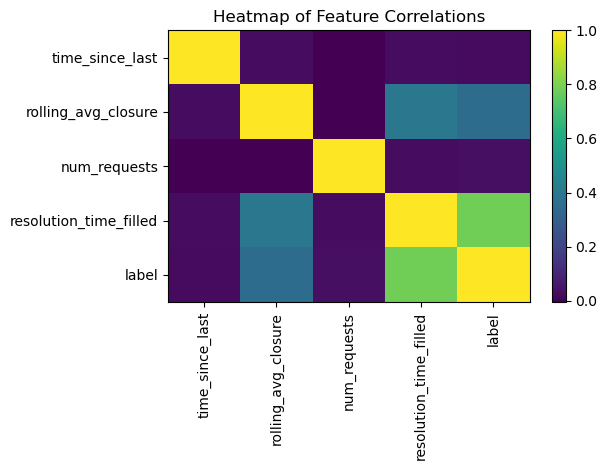

In [111]:
# Identifying neighborhoods strongly correlated with high delays
# Will be useful for filtering or interpretability
features = [
    'time_since_last',
    'rolling_avg_closure',
    'num_requests',
    'resolution_time_filled',
    'label'
]

df['label'] = ((df['is_closed'] == 0) | (df['resolution_time_filled'] > 30)).astype(int)

# Compute and plot heatmap
corr_matrix = df[features].corr()
plt.figure()
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.title('Heatmap of Feature Correlations')
plt.tight_layout()
plt.show()

In [114]:
# Finalizing features: selecting core, engineered, and contextual variables
core_cat = ['neighborhood', 'request_type_name']
engineered_num = ['time_since_last', 'rolling_avg_closure']
context_cat = ['num_requests', 'num_requests_capped', 'dept', 'origin',
               'council_district', 'public_access_level']
features = core_cat + engineered_num

X = df[features]
y = df['label']

# Spliting dataset into training and test sets based on time to avoid data leakage
# 80% train, 20% test
split_idx = int(0.8 * len(df))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [116]:
# Standardizing numeric features and one-hot encode categorical ones
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['time_since_last', 'rolling_avg_closure']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['neighborhood', 'request_type_name'])
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [118]:
# LOGISTIC REGRESSION #

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

pipe_lr = Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

grid_lr = GridSearchCV(pipe_lr, {'model__C': [0.1, 1, 10]}, cv=cv, scoring='precision', n_jobs=-1)

grid_lr.fit(X_train, y_train)

y_pred_lr = grid_lr.predict(X_test)
y_prob_lr = grid_lr.predict_proba(X_test)[:, 1]


print("Logistic Regression Best Params:", grid_lr.best_params_)
print(classification_report(y_test, y_pred_lr, target_names=['<=30 days', '>30 days or open']))

Logistic Regression Best Params: {'model__C': 10}
                  precision    recall  f1-score   support

       <=30 days       0.84      0.74      0.79     40808
>30 days or open       0.58      0.71      0.63     20220

        accuracy                           0.73     61028
       macro avg       0.71      0.72      0.71     61028
    weighted avg       0.75      0.73      0.74     61028



In [120]:
# NAIVE BAYES #

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

pipe_nb = Pipeline([
    ('pre', preprocessor),
    ('to_dense', FunctionTransformer(lambda X: X.toarray(), accept_sparse=True)),
    ('model', GaussianNB())
])

pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
y_prob_nb = pipe_nb.predict_proba(X_test)[:, 1]

print("Naïve Bayes Classification Report:")
print(classification_report(
    y_test, 
    y_pred_nb, 
    target_names=['<=30 days','>30 days or open']
))

Naïve Bayes Classification Report:
                  precision    recall  f1-score   support

       <=30 days       0.76      0.87      0.81     40808
>30 days or open       0.62      0.44      0.51     20220

        accuracy                           0.73     61028
       macro avg       0.69      0.65      0.66     61028
    weighted avg       0.71      0.73      0.71     61028



In [132]:
# RANDOM FOREST CLASSIFIER #

from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=42))])
grid_rf = GridSearchCV(pipe_rf, {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10]},
                       cv=cv, scoring='precision', n_jobs=-1)
grid_rf.fit(X_train, y_train)
y_pred_rf_imbal = grid_rf.predict(X_test)
y_prob_rf_imbal = grid_rf.predict_proba(X_test)[:, 1]
print("Random Forest Best Params:", grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf_imbal, target_names=['<=30 days', '>30 days or open'], zero_division=0))



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Best Params: {'model__max_depth': 5, 'model__n_estimators': 200}
                  precision    recall  f1-score   support

       <=30 days       0.68      1.00      0.81     40808
>30 days or open       0.97      0.07      0.13     20220

        accuracy                           0.69     61028
       macro avg       0.83      0.53      0.47     61028
    weighted avg       0.78      0.69      0.59     61028



In [125]:
#Balanced Random Forest (class_weight = ‘balanced’)

pipe_rf_balanced = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
])

pipe_rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = pipe_rf_balanced.predict(X_test)
y_prob_rf_bal = pipe_rf_balanced.predict_proba(X_test)[:, 1]

print("Balanced Random Forest:")
print(classification_report(y_test, y_pred_rf_bal, target_names=['<=30 days', '>30 days or open']))

Balanced Random Forest:
                  precision    recall  f1-score   support

       <=30 days       0.83      0.67      0.74     40808
>30 days or open       0.52      0.72      0.60     20220

        accuracy                           0.68     61028
       macro avg       0.67      0.69      0.67     61028
    weighted avg       0.72      0.68      0.69     61028



In [126]:
from sklearn.metrics import f1_score

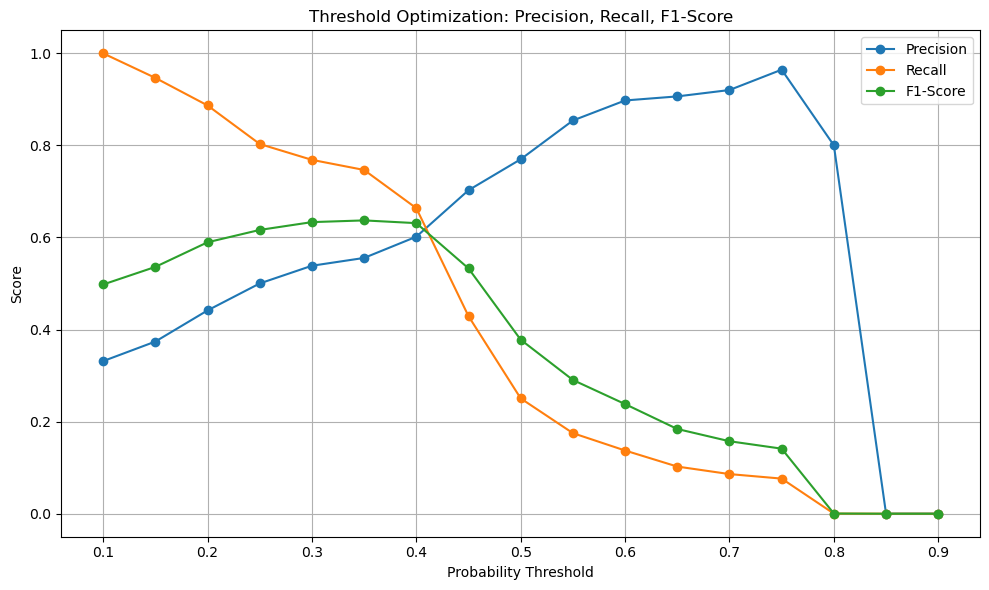

In [134]:
# Evaluating how Precision, Recall, and F1 change with different probability thresholds
# Will help pick the optimal balance between false alarms and misses
thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1_vals = [], [], []

for t in thresholds:
    preds = (prob_preds > t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds))
    f1_vals.append(f1_score(y_test, preds, zero_division=0))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='o', label="Recall")
plt.plot(thresholds, f1_vals, marker='o', label="F1-Score")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization: Precision, Recall, F1-Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Voting Classifier (LogReg + RF) with Threshold = 0.3
# Combining Logistic and Random Forest using soft voting
# Applying a custom threshold (0.3) to boost recall on delayed/open cases

log_reg_model = LogisticRegression(C=10, max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

voting_clf = Pipeline([
    ('pre', preprocessor),
    ('model', VotingClassifier(
        estimators=[
            ('lr', log_reg_model),
            ('rf', rf_model)
        ],
        voting='soft'
    ))
])

voting_clf.fit(X_train, y_train)

# Get probabilities and apply custom threshold
prob_preds = voting_clf.predict_proba(X_test)[:, 1]
y_pred_thresh = (prob_preds > 0.3).astype(int)

print("Voting Classifier with threshold = 0.3")
print(classification_report(y_test, y_pred_thresh, target_names=['<=30 days', '>30 days or open']))

Voting Classifier with threshold = 0.3
                  precision    recall  f1-score   support

       <=30 days       0.85      0.67      0.75     40808
>30 days or open       0.54      0.77      0.63     20220

        accuracy                           0.71     61028
       macro avg       0.70      0.72      0.69     61028
    weighted avg       0.75      0.71      0.71     61028



In [40]:
# Collecting predictions from each model and compare their precision, recall, f1, accuracy
results = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Random Forest (imbalanced)": y_pred_rf_imbal,
    "Random Forest (balanced)": y_pred_rf_bal,
    "Voting (threshold 0.3)": y_pred_thresh
}

# Create a results list
metrics = []

for model_name, preds in results.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    metrics.append({
        "Model": model_name,
        "Precision (Delay)": round(precision, 2),
        "Recall (Delay)": round(recall, 2),
        "F1-Score (Delay)": round(f1, 2),
        "Accuracy": round(accuracy, 2)
    })

# Create DataFrame
comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.set_index("Model")
comparison_df

,Precision (Delay),Recall (Delay),F1-Score (Delay),Accuracy
Model,,,,
Logistic Regression,0.58,0.71,0.63,0.73
Naive Bayes,0.62,0.44,0.51,0.73
Random Forest (imbalanced),0.97,0.07,0.13,0.69
Random Forest (balanced),0.52,0.72,0.60,0.68
Voting (threshold 0.3),0.54,0.77,0.63,0.71


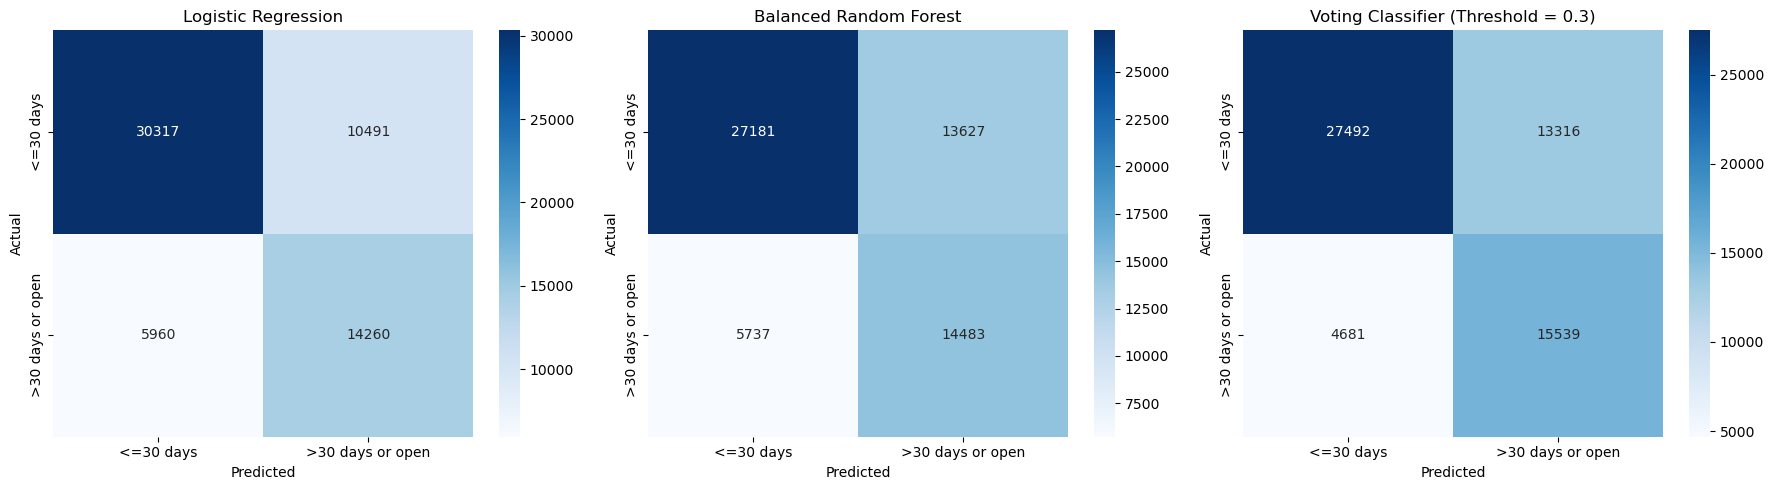

In [42]:
# Visualizing confusion matrices for the top 3 models
# Will be useful to inspect false positives and false negatives

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (y_pred, title) in zip(
    axes,
    [
        (y_pred_lr, "Logistic Regression"),
        (y_pred_rf_bal, "Balanced Random Forest"),
        (y_pred_thresh, "Voting Classifier (Threshold = 0.3)")
    ]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=30 days', '>30 days or open'],
                yticklabels=['<=30 days', '>30 days or open'],
                ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

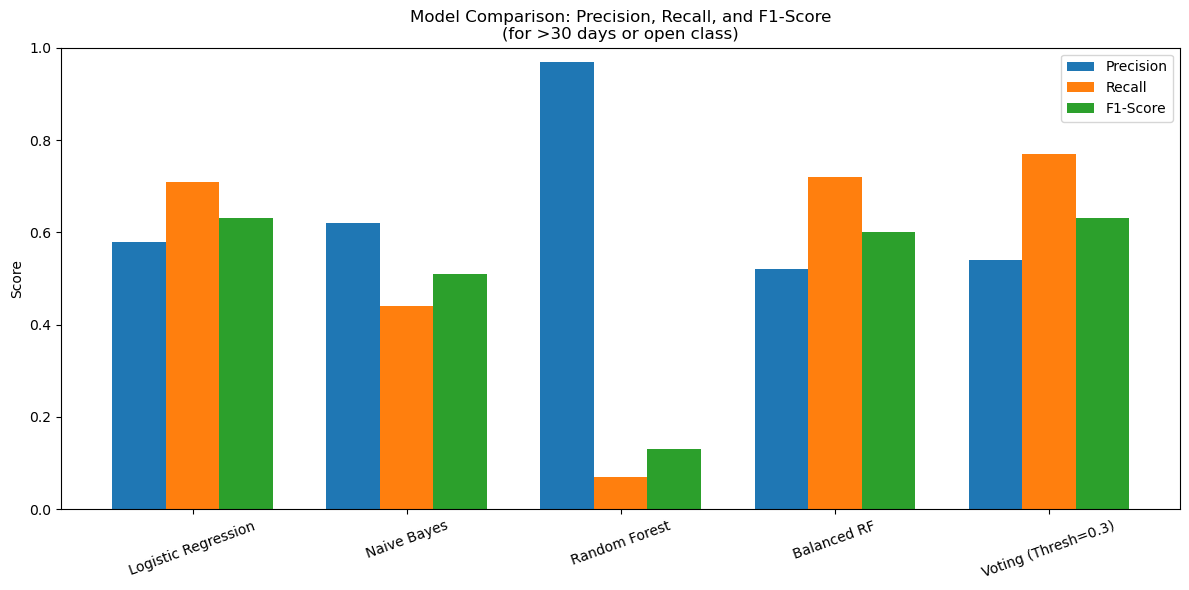

In [44]:
# Comparing Precision, Recall, and F1 visually across all models

models = [
    "Logistic Regression",
    "Naive Bayes",
    "Random Forest",
    "Balanced RF",
    "Voting (Thresh=0.3)"
]

# Metrics: precision, recall, f1-score (for '>30 days or open' class)
precision = [0.58, 0.62, 0.97, 0.52, 0.54]
recall = [0.71, 0.44, 0.07, 0.72, 0.77]
f1_score = [0.63, 0.51, 0.13, 0.60, 0.63]

x = np.arange(len(models))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1_score, width, label='F1-Score')

# Labels and titles
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Precision, Recall, and F1-Score\n(for >30 days or open class)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

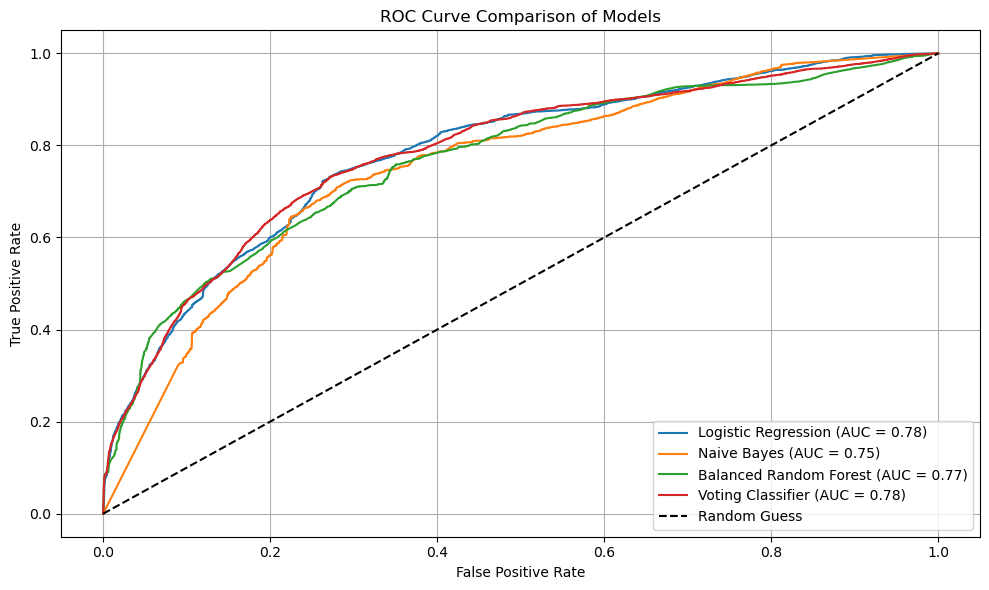

In [46]:
# Plotting ROC curves for multiple models
# Will show trade-off between true positive rate and false positive rate
from sklearn.metrics import roc_curve, auc


# Get predicted probabilities for each model
proba_lr = grid_lr.predict_proba(X_test)[:, 1]
proba_nb = pipe_nb.predict_proba(X_test)[:, 1]
proba_rf = pipe_rf_balanced.predict_proba(X_test)[:, 1]
proba_voting = voting_clf.predict_proba(X_test)[:, 1]

# Compute ROC curves and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, proba_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_vote, tpr_vote, _ = roc_curve(y_test, proba_voting)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_vote = auc(fpr_vote, tpr_vote)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Balanced Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_vote, tpr_vote, label=f'Voting Classifier (AUC = {roc_auc_vote:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('ROC Curve Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

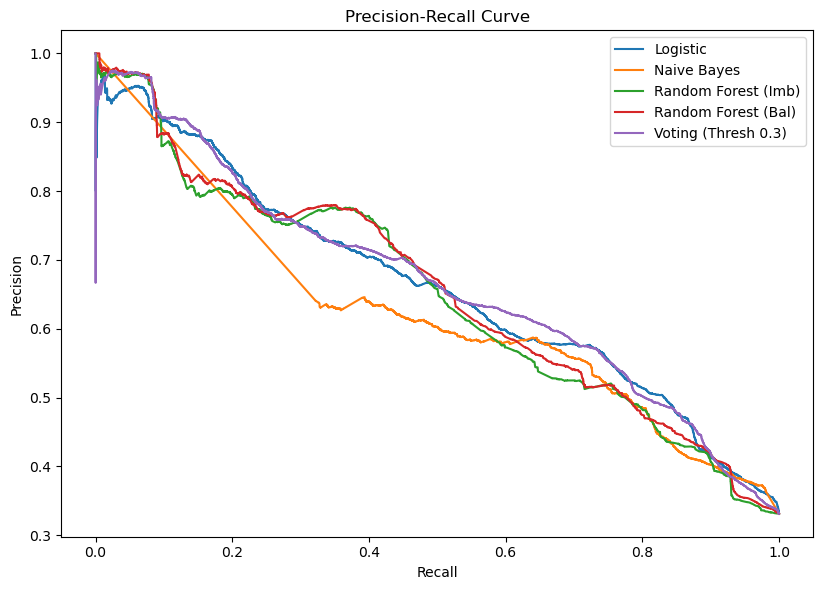

In [58]:
# Comparing PR curves to evaluate models when positive class is less frequent
plt.figure(figsize=(16, 6))


# ----------- PR CURVE -----------
plt.subplot(1, 2, 2)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_nb, rec_nb, _ = precision_recall_curve(y_test, y_prob_nb)
prec_rf_imbal, rec_rf_imbal, _ = precision_recall_curve(y_test, y_prob_rf_imbal)
prec_rf_bal, rec_rf_bal, _ = precision_recall_curve(y_test, y_prob_rf_bal)
prec_thresh, rec_thresh, _ = precision_recall_curve(y_test, prob_preds)

plt.plot(rec_lr, prec_lr, label="Logistic")
plt.plot(rec_nb, prec_nb, label="Naive Bayes")
plt.plot(rec_rf_imbal, prec_rf_imbal, label="Random Forest (Imb)")
plt.plot(rec_rf_bal, prec_rf_bal, label="Random Forest (Bal)")
plt.plot(rec_thresh, prec_thresh, label="Voting (Thresh 0.3)")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

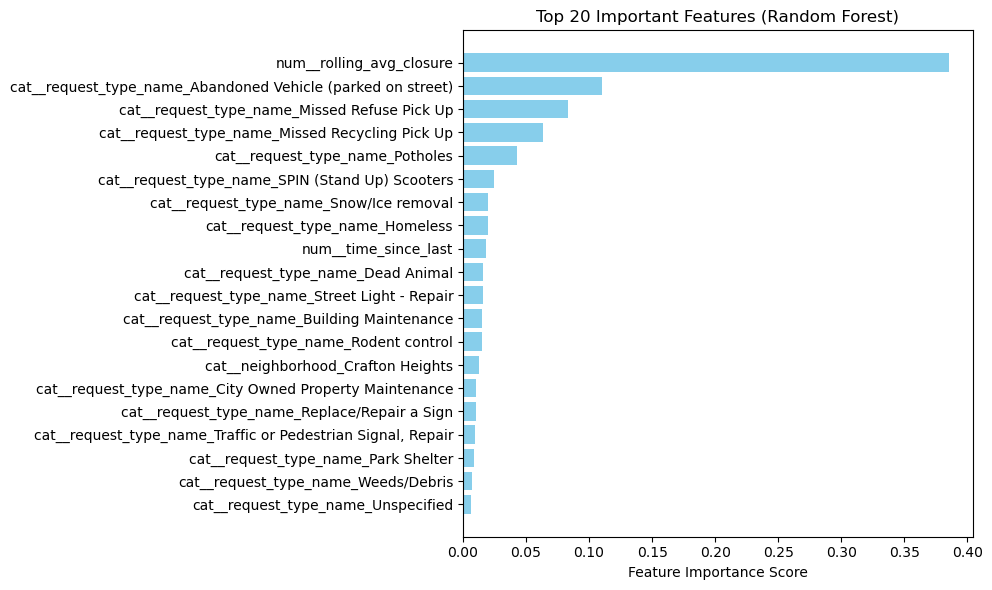

In [76]:
# Using feature_importances_ to see which features matter most
rf_model_bal = pipe_rf_balanced.named_steps['model']

# 2. Get feature names after preprocessing (from ColumnTransformer)
feature_names = preprocessor.get_feature_names_out()

# 3. Pair feature importances with their names
importances = rf_model_bal.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# 4. Sort and display top 20 features
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).head(20)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

In [65]:
# SVM - Support Vector Machine # - has taken over 98 minutes - cell below is a different implementation

from sklearn.svm import SVC

# pipe_svm = Pipeline([('pre', preprocessor), ('model', SVC())])
# grid_svm = GridSearchCV(pipe_svm, {'model__C': [0.1, 1, 10]}, cv=cv, scoring='precision', n_jobs=-1)
# grid_svm.fit(X_train, y_train)
# y_pred = grid_svm.predict(X_test)
# print("SVM Best Params:", grid_svm.best_params_)
# print(classification_report(y_test, y_pred, target_names=['<=30 days', '>30 days or open']))


In [66]:
from sklearn.svm import LinearSVC
pipe_svm = Pipeline([
    ('pre', preprocessor),
    ('model', LinearSVC(max_iter=10_000, C=1.0))
])
pipe_svm.fit(X_train, y_train)

X_sub, y_sub = X_train.sample(50_000, random_state=42), y_train.sample(50_000, random_state=42)
grid_svm = GridSearchCV(pipe_svm, {'model__C':[0.1,1,10]}, cv=3, n_jobs=-1)
grid_svm.fit(X_sub, y_sub)

from sklearn.linear_model import SGDClassifier
pipe_sgd = Pipeline([
    ('pre', preprocessor),
    ('model', SGDClassifier(loss='hinge', max_iter=5_000))
])
pipe_sgd.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_since_last',
                                                   'rolling_avg_closure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighborhood',
                                                   'request_type_name'])])),
                ('model', SGDClassifier(max_iter=5000))])

In [85]:
# TESTING!! #

# # MODEL BUILDING & VALIDATION #
# models = {
#     "LogisticRegression": LogisticRegression(max_iter=1000),
#     "NaiveBayes":         GaussianNB(),
#     "RandomForest":       RandomForestClassifier(random_state=42),
#     "SVM":                SVC()
# }
# param_grids = {
#     "LogisticRegression": {"model__C": [0.1, 1, 10]},
#     "NaiveBayes":         {},
#     "RandomForest":       {"model__n_estimators": [100,200], "model__max_depth": [5,10]},
#     "SVM":                {"model__C": [0.1, 1, 10]}
# }

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# results = []

# for name, clf in models.items():
#     pipe = Pipeline([("pre", preprocessor), ("model", clf)])
#     grid = GridSearchCV(pipe, param_grids[name], cv=skf,
#                         scoring="precision", n_jobs=-1)
#     grid.fit(X_train, y_train)
#     y_pred = grid.predict(X_test)
#     results.append({
#         "Model":     name,
#         "Accuracy":  accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall":    recall_score(y_test, y_pred),
#         "Best_Params": grid.best_params_
#     })

# results_df = pd.DataFrame(results)
# print("\nModel comparison:\n", results_df)